In [19]:
import pandas as pd
import numpy as np
import sklearn 
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv('/Users/priyanshugupta/Desktop/scikit learn/advertising.csv')
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


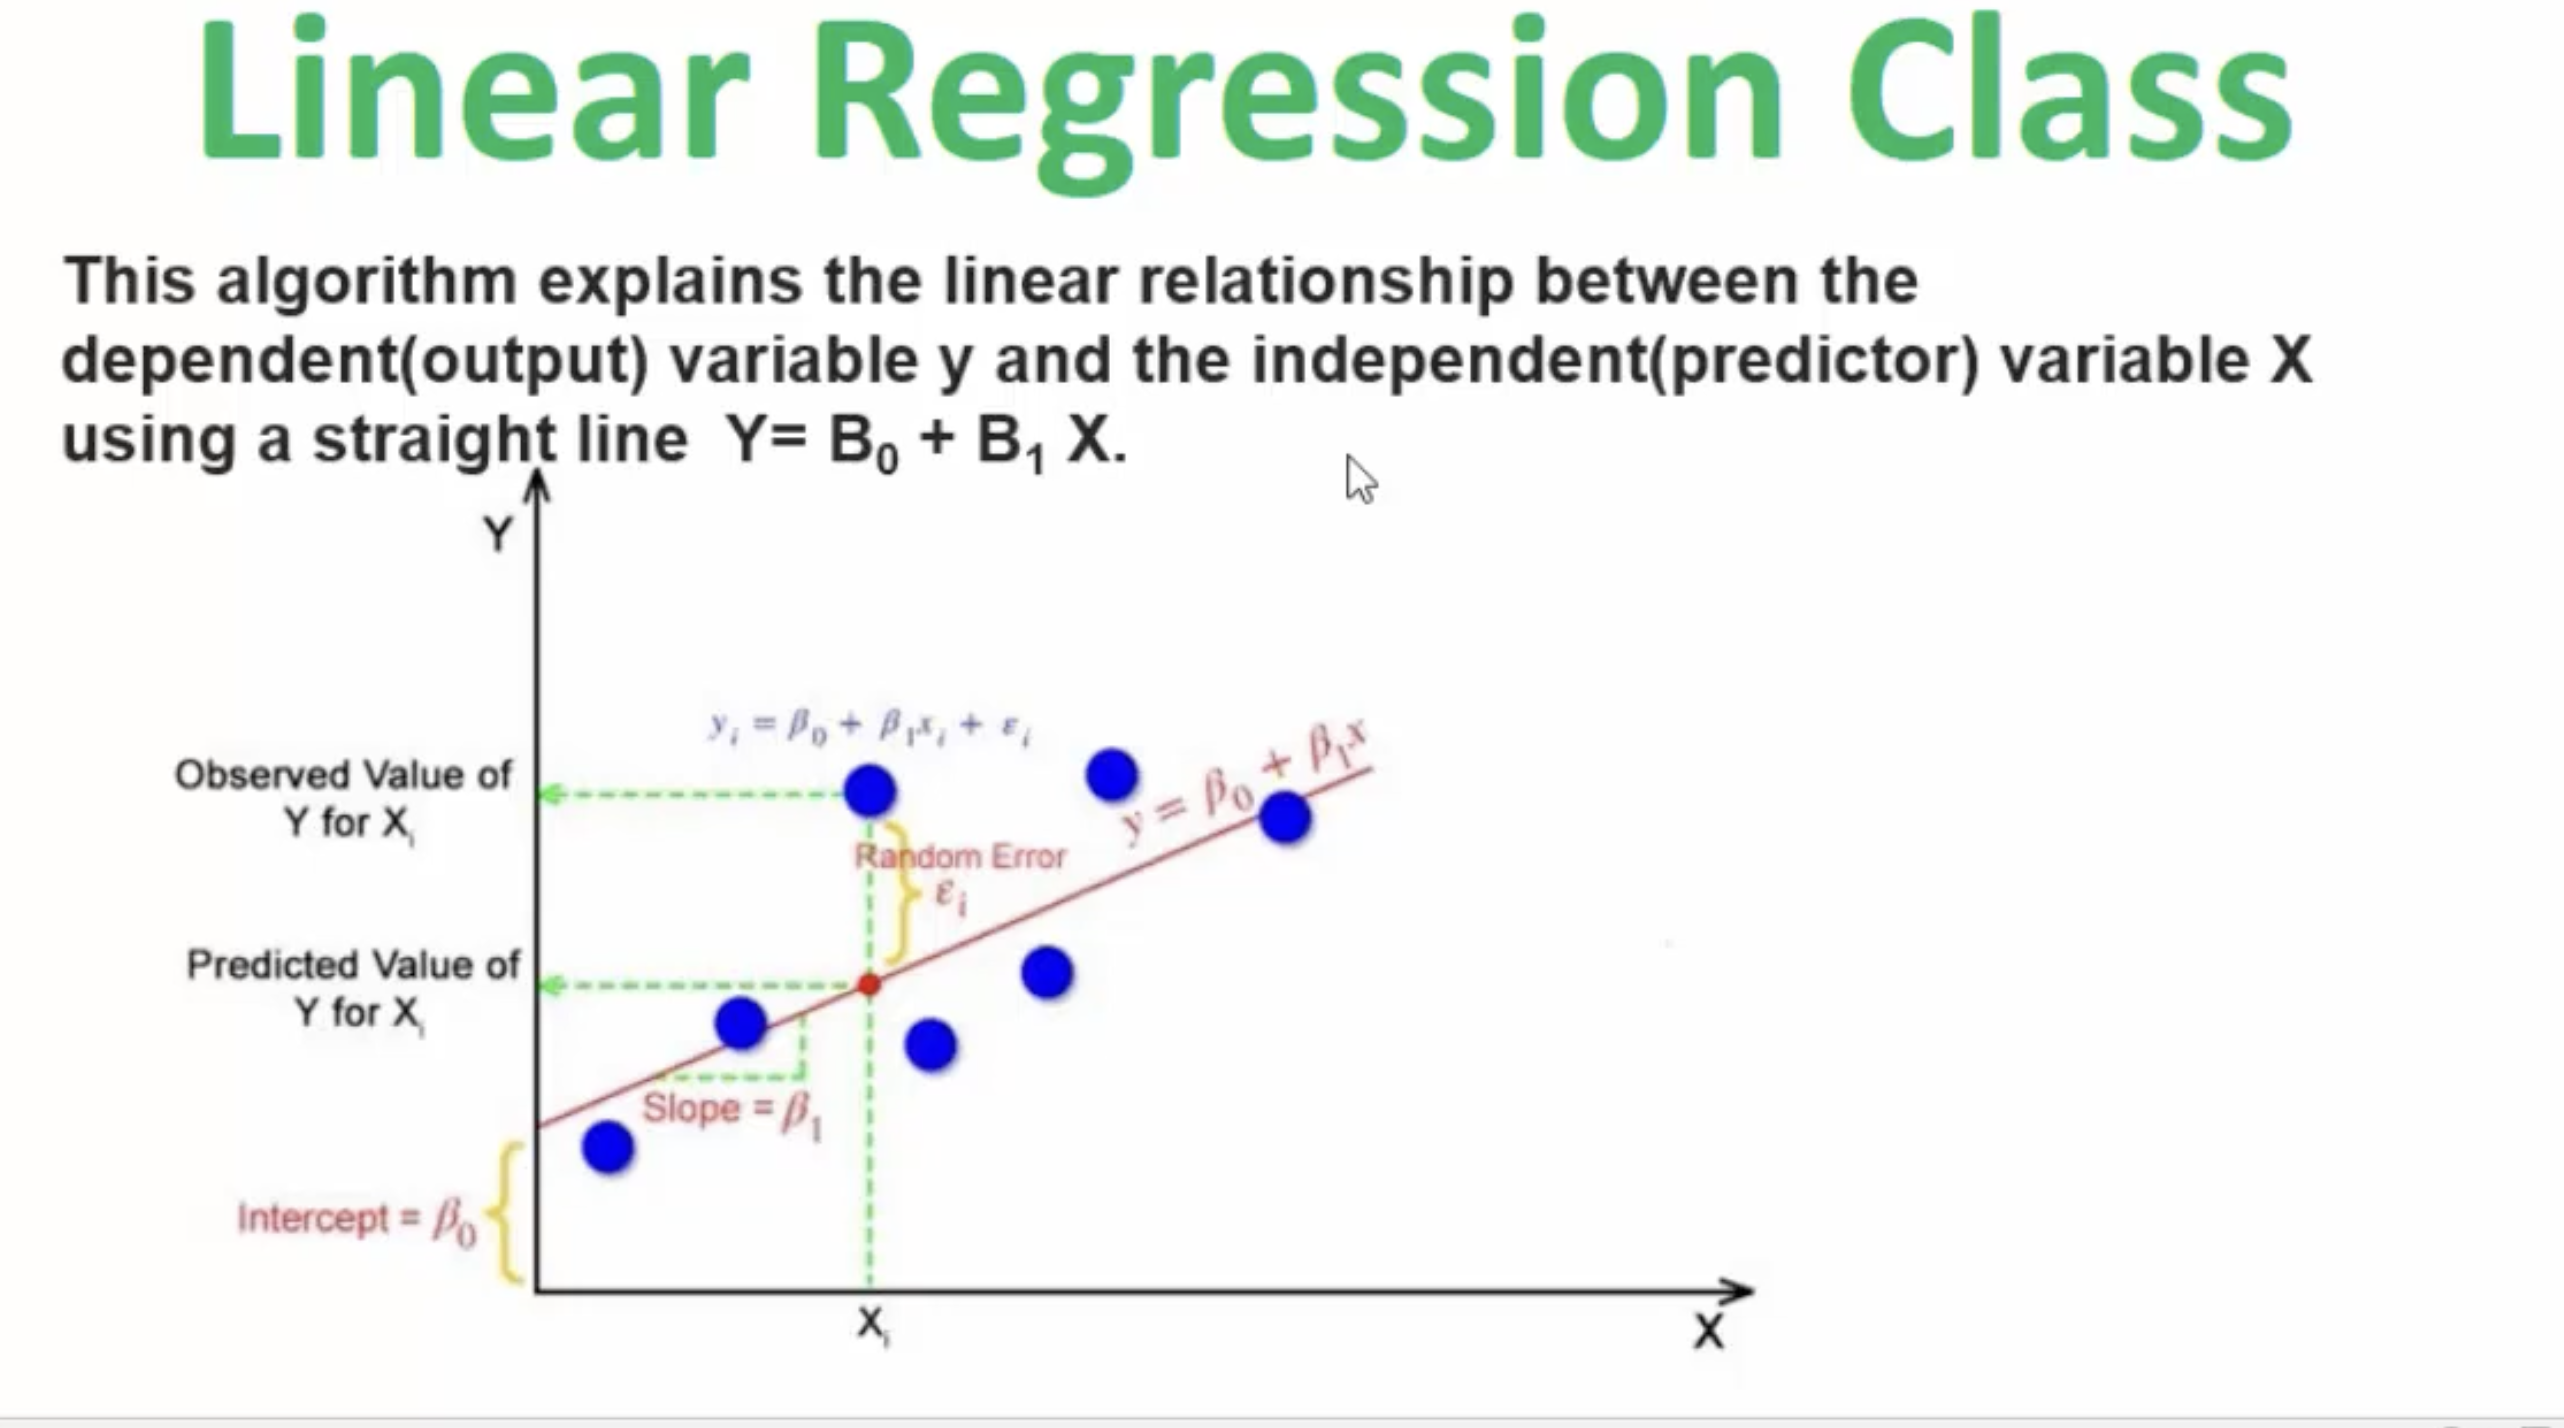

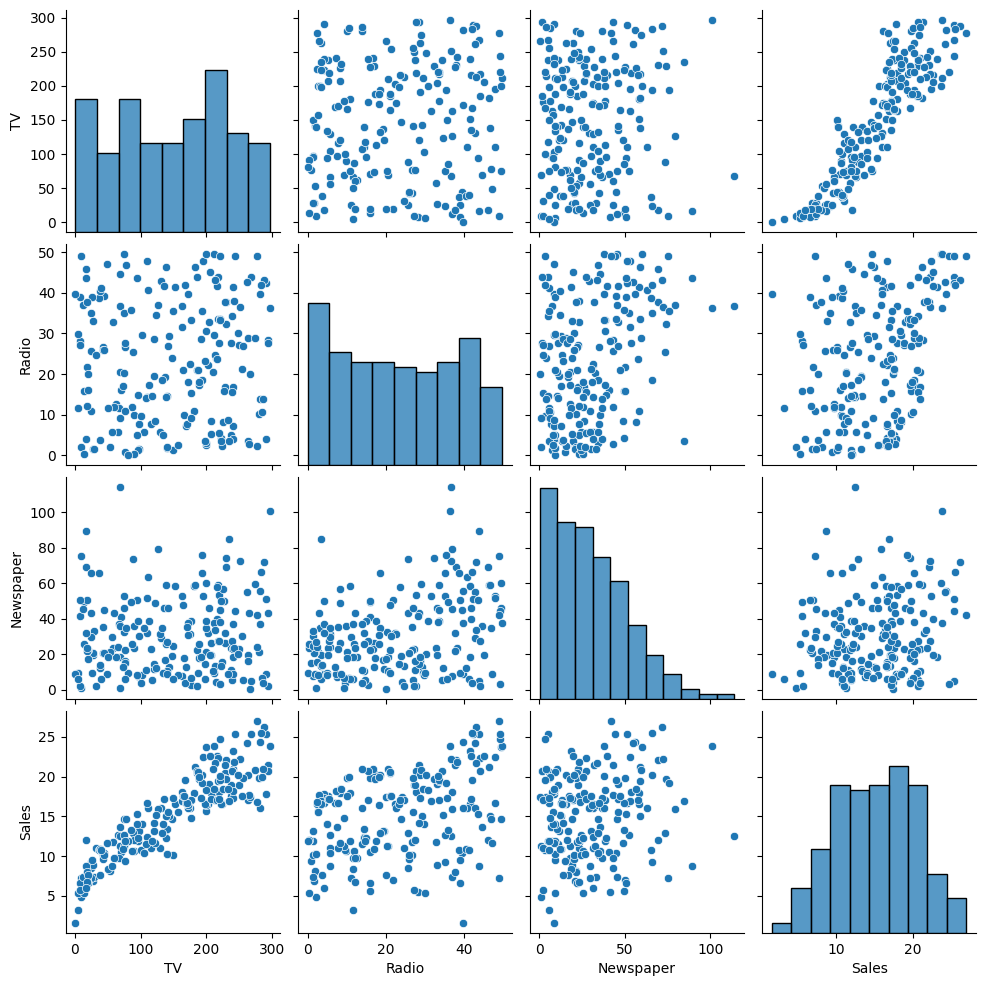

In [20]:
sns.pairplot(df)

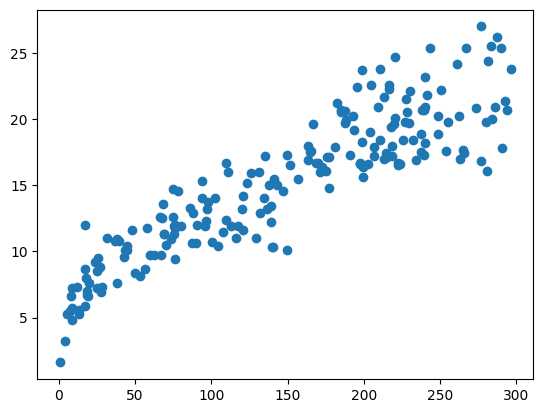

In [21]:
plt.scatter(x=df['TV'],y=df['Sales'])

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.iloc[:,:-1],df.iloc[:,-1],test_size=0.2,random_state=12)

In [23]:
X_train,y_train

(        TV  Radio  Newspaper
 77   120.5   28.5       14.2
 47   239.9   41.5       18.5
 94   107.4   14.0       10.9
 14   204.1   32.9       46.0
 41   177.0   33.4       38.7
 ..     ...    ...        ...
 3    151.5   41.3       58.5
 130    0.7   39.6        8.7
 134   36.9   38.6       65.6
 155    4.1   11.6        5.7
 75    16.9   43.7       89.4
 
 [160 rows x 3 columns],
 77     14.2
 47     23.2
 94     11.5
 14     19.0
 41     17.1
        ... 
 3      16.5
 130     1.6
 134    10.8
 155     3.2
 75      8.7
 Name: Sales, Length: 160, dtype: float64)

## Linear Regression

In [24]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

## to train the model 

lr.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
## to test model
y_pred=lr.predict(X_test)
y_pred

array([18.64910113,  8.29177588,  7.99702802, 17.81872682, 13.47236506,
       18.77827836, 23.20490618,  9.98922127, 12.58190652, 13.2724821 ,
       16.78896409, 14.42116039,  8.23498793, 15.10641783, 24.67017968,
        9.87321364, 12.57394489, 12.14777395, 16.8434818 , 16.8633331 ,
       20.58382312,  9.85058808, 24.23099497,  9.1420435 , 18.11228775,
       11.12859177, 16.22247508, 12.0921209 ,  5.43154553, 10.44448633,
       10.17604161, 24.58632395, 17.7708722 , 21.91896918,  7.03996245,
       19.4315987 , 14.58519613, 20.64159774, 11.38839375, 10.49421061])

## To check model accuracy and correctness we use R2_Score

In [26]:
from sklearn.metrics import r2_score,mean_absolute_error
mean_absolute_error(y_test,y_pred)

1.1792263981480777

In [ ]:
r2_score(y_test,y_pred) ## always test comes before the prediciton

0.930053801697557

## Predicitive system

In [29]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [50]:
def predict_sys(tv_budget,radio_budget,newspaper_budget):
    features=np.array([[tv_budget,radio_budget,newspaper_budget]])
    results=lr.predict(features).reshape(1,-1)
    return results[0]

In [43]:
df.iloc[0]

TV           230.1
Radio         37.8
Newspaper     69.2
Sales         22.1
Name: 0, dtype: float64

In [44]:
tv_budget=230.1
radio_budget=37.8
newspaper_budget=69.2
sales_budget=22.1


In [51]:
sales=predict_sys(tv_budget,radio_budget,newspaper_budget)

/Users/priyanshugupta/Desktop/scikit learn/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [52]:
sales

array([20.97233341])

In [53]:
import pickle 
## converting model to a file 
## i want to save my model into a file
## used to save model
pickle.dump(lr,open('linear_regression_model.pkl','wb'))